<a href="https://colab.research.google.com/github/Sargam2808/DEEP_LEARNING_LAB/blob/main/EXP_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT 8

Installing Libraries

In [1]:
!pip install torch torchvision matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Dataset and spliting

In [2]:
transform = transforms.ToTensor()

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]


Visualizing Data

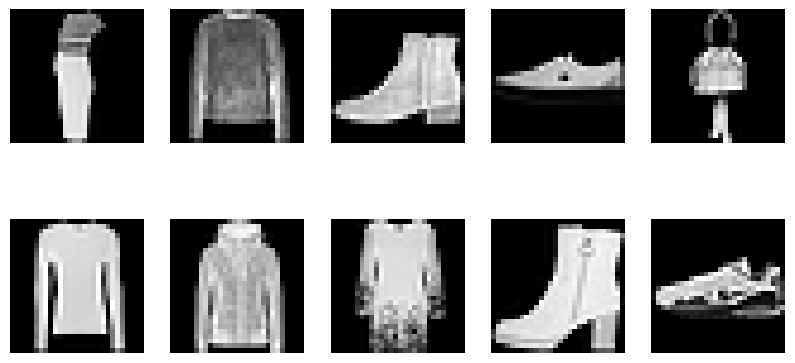

In [3]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

Autoencoder Model

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,784),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = x.view(-1,784)
        z = self.encoder(x)
        return self.decoder(z)

Train Function

In [5]:
def train_ae(latent_dim, optimizer_name, loss_fn, epochs=3):
    model = Autoencoder(latent_dim).to(device)

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.001)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images,_ in train_loader:
            images = images.to(device).view(-1,784)

            out = model(images)
            loss = loss_fn(out, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_losses.append(train_loss/len(train_loader))

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images,_ in val_loader:
                images = images.to(device).view(-1,784)
                out = model(images)
                val_loss += loss_fn(out, images).item()

        val_losses.append(val_loss/len(val_loader))

    return model, train_losses, val_losses

Autoencoder

In [6]:
latent_dims = [2,8,16,32]
optimizers_list = ["Adam","SGD","RMSprop"]
losses = {"BCE": nn.BCELoss(), "MSE": nn.MSELoss()}

results = {}

for dim in latent_dims:
    for opt in optimizers_list:
        for loss_name, loss_fn in losses.items():

            print(f"Running: dim={dim}, opt={opt}, loss={loss_name}")
            model, train_l, val_l = train_ae(dim, opt, loss_fn)

            results[(dim,opt,loss_name)] = (train_l, val_l)

Running: dim=2, opt=Adam, loss=BCE
Running: dim=2, opt=Adam, loss=MSE
Running: dim=2, opt=SGD, loss=BCE
Running: dim=2, opt=SGD, loss=MSE
Running: dim=2, opt=RMSprop, loss=BCE
Running: dim=2, opt=RMSprop, loss=MSE
Running: dim=8, opt=Adam, loss=BCE
Running: dim=8, opt=Adam, loss=MSE
Running: dim=8, opt=SGD, loss=BCE
Running: dim=8, opt=SGD, loss=MSE
Running: dim=8, opt=RMSprop, loss=BCE
Running: dim=8, opt=RMSprop, loss=MSE
Running: dim=16, opt=Adam, loss=BCE
Running: dim=16, opt=Adam, loss=MSE
Running: dim=16, opt=SGD, loss=BCE
Running: dim=16, opt=SGD, loss=MSE
Running: dim=16, opt=RMSprop, loss=BCE
Running: dim=16, opt=RMSprop, loss=MSE
Running: dim=32, opt=Adam, loss=BCE
Running: dim=32, opt=Adam, loss=MSE
Running: dim=32, opt=SGD, loss=BCE
Running: dim=32, opt=SGD, loss=MSE
Running: dim=32, opt=RMSprop, loss=BCE
Running: dim=32, opt=RMSprop, loss=MSE


Loss Visualization

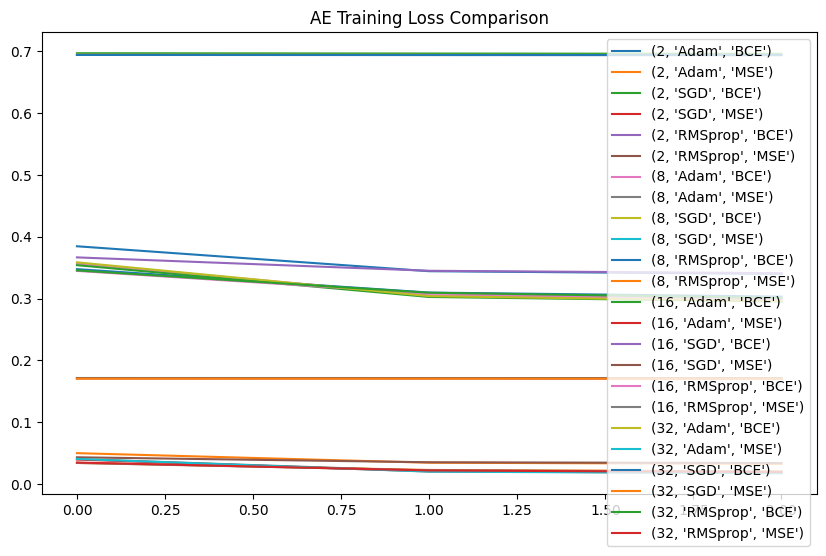

In [7]:
plt.figure(figsize=(10,6))

for key, (train_l, _) in results.items():
    plt.plot(train_l, label=f"{key}")

plt.legend()
plt.title("AE Training Loss Comparison")
plt.show()

Reconstruction

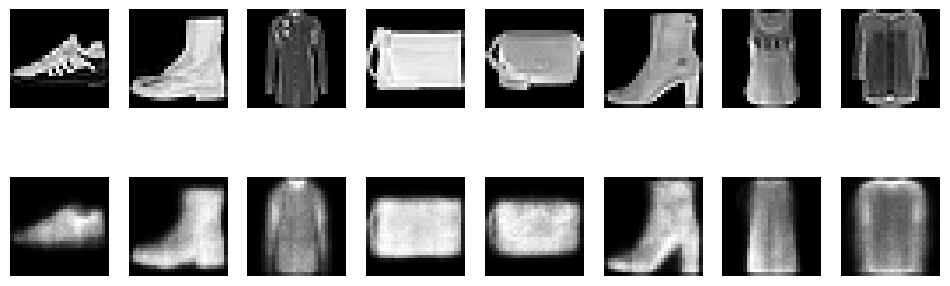

In [8]:
model.eval()
images,_ = next(iter(test_loader))

with torch.no_grad():
    recon = model(images.to(device).view(-1,784))

fig, axes = plt.subplots(2,8, figsize=(12,4))
for i in range(8):
    axes[0,i].imshow(images[i].squeeze(), cmap='gray')
    axes[1,i].imshow(recon[i].cpu().view(28,28), cmap='gray')
    axes[0,i].axis('off')
    axes[1,i].axis('off')
plt.show()

VAE MODEL

In [9]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(784,128)
        self.fc_mu = nn.Linear(128,latent_dim)
        self.fc_logvar = nn.Linear(128,latent_dim)
        self.fc2 = nn.Linear(latent_dim,128)
        self.fc3 = nn.Linear(128,784)

    def encode(self,x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self,z):
        return torch.sigmoid(self.fc3(torch.relu(self.fc2(z))))

    def forward(self,x):
        x = x.view(-1,784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu,logvar)
        return self.decode(z), mu, logvar

VAE LOSS

In [10]:
def vae_loss(recon,x,mu,logvar):
    BCE = nn.functional.binary_cross_entropy(recon,x.view(-1,784), reduction='sum')
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KL

Training VAE

In [12]:
vae_results = {}   # 🔥 ADD THIS LINE

for dim in [2,16]:
    vae = VAE(dim).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=0.001)

    losses_list = []

    for epoch in range(3):
        total_loss = 0
        for images,_ in train_loader:
            images = images.to(device)

            recon, mu, logvar = vae(images)
            loss = vae_loss(recon, images, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses_list.append(total_loss/len(train_loader))

    vae_results[dim] = losses_list

VAE and AE Loss

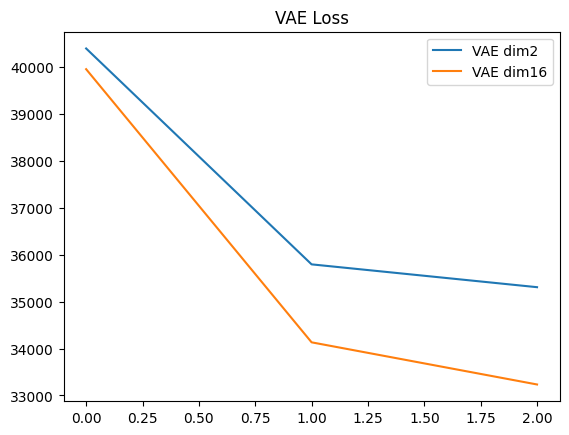

In [13]:
plt.plot(list(vae_results[2]), label="VAE dim2")
plt.plot(list(vae_results[16]), label="VAE dim16")
plt.legend()
plt.title("VAE Loss")
plt.show()

Latent Space(2c)

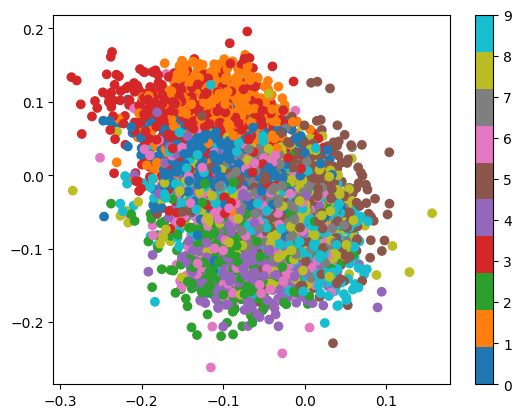

In [14]:
vae2 = VAE(2).to(device)

z_list, labels_list = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu,_ = vae2.encode(images.view(-1,784))
        z_list.append(mu.cpu())
        labels_list.append(labels)

z = torch.cat(z_list).numpy()
labels = torch.cat(labels_list).numpy()

plt.scatter(z[:,0], z[:,1], c=labels, cmap='tab10')
plt.colorbar()
plt.show()

Generation

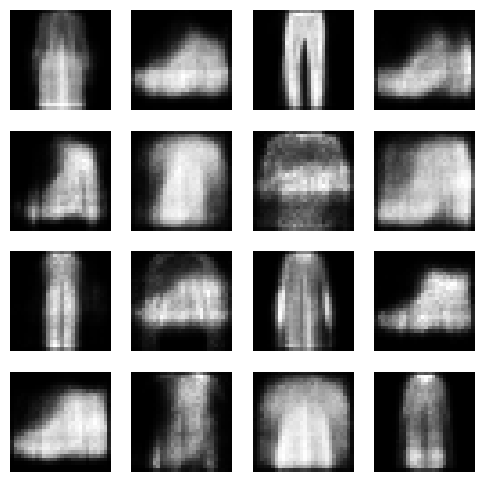

In [15]:
z = torch.randn(16,16).to(device)

with torch.no_grad():
    samples = vae.decode(z).cpu().view(-1,28,28)

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i], cmap='gray')
    plt.axis('off')
plt.show()

Interpolation

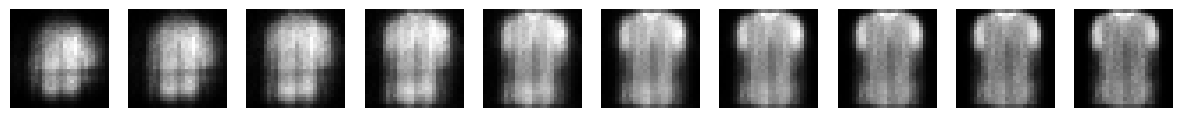

In [17]:
z1 = torch.randn(1,16).to(device)
z2 = torch.randn(1,16).to(device)

alphas = torch.linspace(0,1,10)

fig, axes = plt.subplots(1,10, figsize=(15,2))

for i, alpha in enumerate(alphas):
    z = (1-alpha)*z1 + alpha*z2

    img = vae.decode(z).detach().cpu().view(28,28).numpy()  # 🔥 FIX

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.show()